In [62]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import pinnde as p
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

In [52]:

x_min, x_max = 0.0, 1.0

t_min, t_max = 0.0, 1.0

alpha = 0.0005


In [96]:

timerange = [t_min, t_max]
tre = p.domain.Time_NRect(1, [x_min], [x_max], timerange)

bdryfunc = lambda t, x1: tf.zeros_like(x1)
bound = p.boundaries.dirichlet(tre, [bdryfunc])

sigma = 0.1
u0func = lambda x1: tf.exp(-((x1 - 0.5)**2) / (2 * sigma**2))
inits = p.initials.initials(tre, [u0func])

dat = p.data.timepinndata(tre, bound, inits, 20000, 1000, 1000)

eqn = f"ut - {alpha} * ux1x1"
mymodel = p.models.pinn(dat, [eqn], layers=6, units=50)
mymodel.train(1000)


Model: "functional_17"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_34      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_35      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalize_69        │ (None, 1)         │          0 │ input_layer_34[0… │
│ (Normalize)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalize_71        │ (None, 1)         │          0 │ input_layer_35[0… │
│ (Normalize)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_17      │ (None, 2)         │          0 │ normalize_69[0][… │
│ (Concatenate)       │                   │            │ normalize_71[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_93 (Dense)    │ (None, 50)        │        150 │ concatenate_17[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_94 (Dense)    │ (None, 50)        │      2,550 │ dense_93[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_95 (Dense)    │ (None, 50)        │      2,550 │ dense_94[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_96 (Dense)    │ (None, 50)        │      2,550 │ dense_95[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_97 (Dense)    │ (None, 50)        │      2,550 │ dense_96[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_98 (Dense)    │ (None, 50)        │      2,550 │ dense_97[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_99 (Dense)    │ (None, 1)         │         51 │ dense_98[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 12,951 (50.59 KB)

 Trainable params: 12,951 (50.59 KB)

 Non-trainable params: 0 (0.00 B)

/Users/mohamedwalidchabchi/stage /venv311/lib/python3.11/site-packages/keras/src/models/functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_178', 'keras_tensor_180']
Received: inputs=['Tensor(shape=(1000, 1))', ['Tensor(shape=(1000, 1))']]
  warnings.warn(msg)


CLP loss, BC loss, IV loss in 0th epoch:  0.0547,  0.0128,  0.1319.
CLP loss, BC loss, IV loss in 100th epoch:  0.0011,  0.0002,  0.0009.
CLP loss, BC loss, IV loss in 200th epoch:  0.0005,  0.0000,  0.0001.
CLP loss, BC loss, IV loss in 300th epoch:  0.0003,  0.0000,  0.0000.
CLP loss, BC loss, IV loss in 400th epoch:  0.0002,  0.0000,  0.0000.
CLP loss, BC loss, IV loss in 500th epoch:  0.0001,  0.0000,  0.0000.
CLP loss, BC loss, IV loss in 600th epoch:  0.0001,  0.0000,  0.0000.
CLP loss, BC loss, IV loss in 700th epoch:  0.0001,  0.0000,  0.0000.
CLP loss, BC loss, IV loss in 800th epoch:  0.0001,  0.0000,  0.0000.
CLP loss, BC loss, IV loss in 900th epoch:  0.0001,  0.0000,  0.0000.


In [ ]:
x_vals = np.linspace(x_min, x_max, 200)
t_vals = np.linspace(t_min, t_max, 200)
X, T = np.meshgrid(x_vals, t_vals)

network = mymodel.get_network()

T_flat = T.flatten().reshape(-1, 1).astype(np.float32)
X_flat = X.flatten().reshape(-1, 1).astype(np.float32)
U_pinn = network([T_flat, X_flat]).numpy().reshape(X.shape)

U_exact = (sigma / np.sqrt(sigma**2 + 2*alpha*T)) * \
           np.exp(-((X - 0.5)**2) / (2 * (sigma**2 + 2*alpha*T)))

vmin = min(U_pinn.min(), U_exact.min())
vmax = max(U_pinn.max(), U_exact.max())

In [79]:
print("PINN max:", U_pinn.max(), "PINN min:", U_pinn.min())
print("Exact max:", U_exact.max(), "Exact min:", U_exact.min())
print("Différence max:", np.abs(U_pinn - U_exact).max())

PINN max: 1.0012046 PINN min: -0.0077292114
Exact max: 0.999684401217044 Exact min: 3.7266531720786777e-06
Différence max: 0.013587949651604037


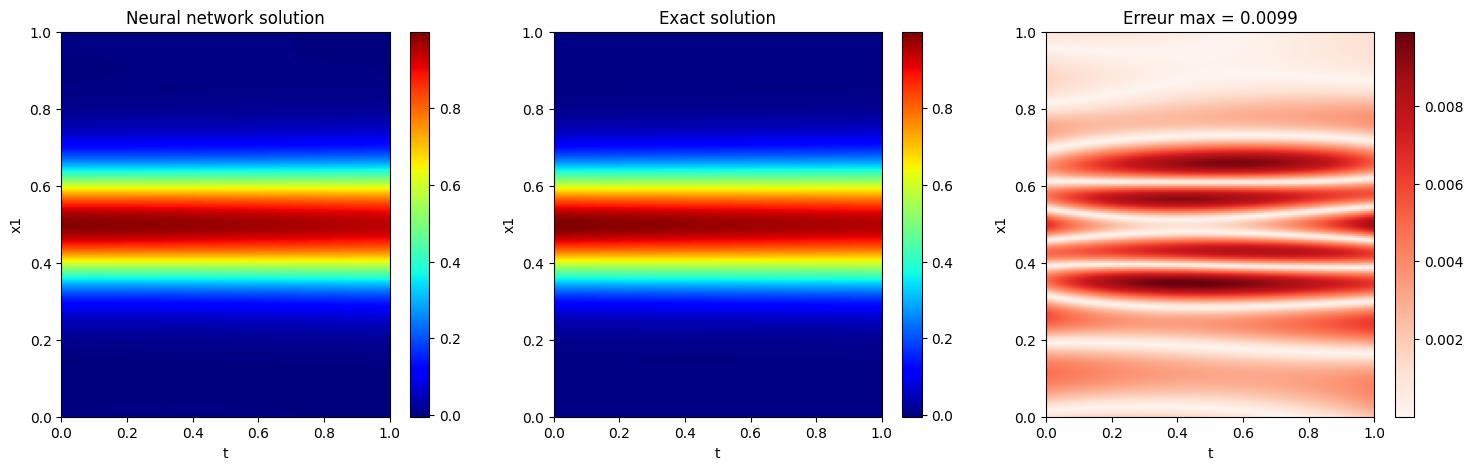

In [98]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

kwargs = dict(cmap='jet', vmin=vmin, vmax=vmax,
              aspect='auto', origin='lower',
              extent=[t_min, t_max, x_min, x_max])

im0 = axes[0].imshow(U_pinn.T, **kwargs)
axes[0].set_title('Neural network solution')
axes[0].set_xlabel('t'); axes[0].set_ylabel('x1')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(U_exact.T, **kwargs)
axes[1].set_title('Exact solution')
axes[1].set_xlabel('t'); axes[1].set_ylabel('x1')
plt.colorbar(im1, ax=axes[1])

# Erreur avec sa propre échelle
im2 = axes[2].imshow(np.abs(U_pinn.T - U_exact.T),
                     cmap='Reds', aspect='auto', origin='lower',
                     extent=[t_min, t_max, x_min, x_max])
axes[2].set_title(f'Erreur max = {np.abs(U_pinn - U_exact).max():.4f}')
axes[2].set_xlabel('t'); axes[2].set_ylabel('x1')
plt.colorbar(im2, ax=axes[2])

plt.show()